In [22]:
import sys
sys.path.append('..')

from diffusion_1d.data.dataset import DiffusionDataset, sin_1d, get_dataloader
from diffusion_1d.utils.diffusion import Diffusion
import gpytorch
import torch
import numpy as np
from tqdm import tqdm
from matplotlib import pyplot as plt

# Inducing points GP

In [ ]:
seed = 42
n_samples = 4000
batch_size = 32
dataset = DiffusionDataset(dataset_name='sin_1d', n_samples=n_samples, seed=seed, x_normalise=False, y_normalise=True)
train_loader, test_loader, val_loader = get_dataloader(dataset, shuffle=True, batch_size=batch_size, train_ratio=0.7, val_ratio=0.3)

In [3]:
class DiffusionGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_dist = gpytorch.variational.CholeskyVariationalDistribution(inducing_points.size(0))
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_dist, learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        # Same kernel: product over x, t, y_t
        self.mean_module = gpytorch.means.LinearMean(input_size=3)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.ProductKernel(
                gpytorch.kernels.MaternKernel(nu=0.5, active_dims=[0]),  # x
                gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[1]),  # t
                gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[2]),   # y_t
            ), 
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [21]:
num_epochs = 200
time_steps = 1000
epoch_update = 10
total_dim = 3
loss_type = "elbo"
num_inducing_points = 500
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# initialise model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
inducing_points = torch.rand(num_inducing_points, total_dim).to(device)
model = DiffusionGP(inducing_points).to(device)
likelihood = likelihood.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
diffusion = Diffusion(T=time_steps, device=device)


best_val_loss = float('inf')
train_losses = []
val_losses = []
if loss_type == "elbo":
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_loader.dataset))
elif loss_type == "mse":
    mll = torch.nn.MSELoss()

# training loop
model.train()
likelihood.train()
for epoch in range(num_epochs):
    train_epoch_loss = 0
    train_num_batches = 0

    for batch in train_loader:
        x = batch['X'].to(device).unsqueeze(1)
        y_0 = batch['y'].to(device)
        t = torch.randint(1, time_steps, (x.shape[0],), device=device).unsqueeze(1)
        noise = torch.randn_like(y_0, device=device)
        y_t = diffusion.q_sample(y_0, t, noise)
        t = t / time_steps # normalise time step

        # Stack x, t, y_t
        if y_t.dim() == 1:
            y_t = y_t.unsqueeze(1)
        z = torch.cat([x, t, y_t], dim=1)

        # Forward pass
        output = model(z)
        if loss_type == "elbo":
            loss = -mll(output, noise)
        elif loss_type == "mse":
            loss = mll(output.mean, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
        train_num_batches += 1
        
    train_losses.append(train_epoch_loss / train_num_batches)

    # Validation phase
    model.eval()
    likelihood.eval()
    val_epoch_loss = 0
    val_num_batches = 0
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for batch in val_loader:
            x = batch['X'].to(device).unsqueeze(1)
            y_0 = batch['y'].to(device)
            t = torch.randint(1, time_steps, (x.shape[0],), device=device).unsqueeze(1)
            noise = torch.randn_like(y_0, device=device)
            y_t = diffusion.q_sample(y_0, t, noise)
            t = t / time_steps # normalise time step
        
            # Stack x, t, y_t
            if y_t.dim() == 1:
                y_t = y_t.unsqueeze(1)
            z = torch.cat([x, t, y_t], dim=1)

            # Forward pass
            output = model(z)
            if loss_type == "elbo":
                loss = -mll(output, noise)
            elif loss_type == "mse":
                loss = mll(output.mean, noise)
            val_epoch_loss += loss.item()
            val_num_batches += 1
    val_losses.append(val_epoch_loss / val_num_batches)
    
    if epoch % epoch_update == 0:
        print(f'Epoch {epoch}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

RuntimeError: grad can be implicitly created only for scalar outputs

In [11]:
num_epochs = 200
time_steps = 1000
epoch_update = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
likelihood = gpytorch.likelihoods.GaussianLikelihood()
inducing_points = torch.rand(256, 3).to(device)
model = DiffusionGP(inducing_points)
elbo = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(dataset))

model = model.to(device)
likelihood = likelihood.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
diffusion = Diffusion(T=time_steps, device=device)

best_val_loss = float('inf')
train_losses = []
val_losses = []

model.train()
likelihood.train()
for epoch in range(num_epochs):
    train_epoch_loss = 0
    train_num_batches = 0

    for batch in train_loader:
        x = batch['x'].to(device)
        y0 = batch['y'].to(device)
        t = torch.randint(1, time_steps, (x.shape[0],), device=device)
        noise = torch.randn_like(y0, device=device)
        y_t = diffusion.q_sample(y0, t, noise)

        t = t / time_steps # normalise time step
        z = torch.stack([x, t, y_t], dim=-1)
        output = model(z)
        loss = -elbo(output, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_epoch_loss += loss.item()
        train_num_batches += 1
        
    train_losses.append(train_epoch_loss / train_num_batches)

    # Validation phase
    model.eval()
    likelihood.eval()
    val_epoch_loss = 0
    val_num_batches = 0
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for batch in val_loader:
            x = batch['x'].to(device)
            y0 = batch['y'].to(device)
            t = torch.randint(1, time_steps, (x.shape[0],), device=device)
            noise = torch.randn_like(y0, device=device)
            y_t = diffusion.q_sample(y0, t, noise)
        
            t = t / time_steps
            z = torch.stack([x, t, y_t], dim=-1)
            output = model(z)
            loss = -elbo(output, noise)

            val_epoch_loss += loss.item()
            val_num_batches += 1
    val_losses.append(val_epoch_loss / val_num_batches)
    
    if epoch % epoch_update == 0:
        print(f'Epoch {epoch}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')


Epoch 0/200, Train Loss: 1.7411, Val Loss: 1.2205


/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


Epoch 10/200, Train Loss: 1.0609, Val Loss: 1.0619
Epoch 20/200, Train Loss: 1.0312, Val Loss: 1.0609
Epoch 30/200, Train Loss: 1.0256, Val Loss: 1.0151
Epoch 40/200, Train Loss: 1.0396, Val Loss: 1.0284
Epoch 50/200, Train Loss: 1.0606, Val Loss: 0.9962
Epoch 60/200, Train Loss: 1.0232, Val Loss: 1.0078
Epoch 70/200, Train Loss: 1.0349, Val Loss: 1.0006


KeyboardInterrupt: 

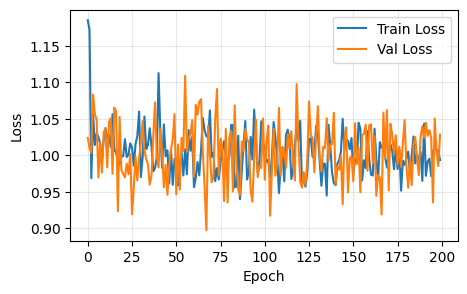

In [20]:
plt.figure(figsize=(5, 3))
plt.grid(alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

In [6]:
def sample_from_model(model, location, num_samples, device):
    y_t = torch.randn(num_samples).to(device)
    x = torch.ones_like(y_t) * location
    diffusion = Diffusion(T=1000, device=device)
    
    model.eval()
    likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for t in range(999, -1, -1):
            t_tensor = torch.ones_like(y_t) * (t+1)
            t_tensor = t_tensor / 1000
            z = torch.stack([x, t_tensor, y_t], dim=-1)
            score = model(z).mean
            y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
            y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
            # y_t = torch.clamp(y_t, min=-3.0, max=3.0)
    return y_t

In [8]:
num_locations = 100
num_samples = 100
locations = torch.linspace(0, 1, num_locations)
results = np.zeros((num_locations,num_samples))
device = torch.device('cpu')

with tqdm(range(len(locations))) as pbar:
    for i, location in enumerate(locations):
        results[i] = sample_from_model(model, location, num_samples, device).detach().numpy()
        pbar.update(1)

# results = results * y_std + y_mean

  8%|▊         | 8/100 [00:08<01:36,  1.05s/it]


KeyboardInterrupt: 

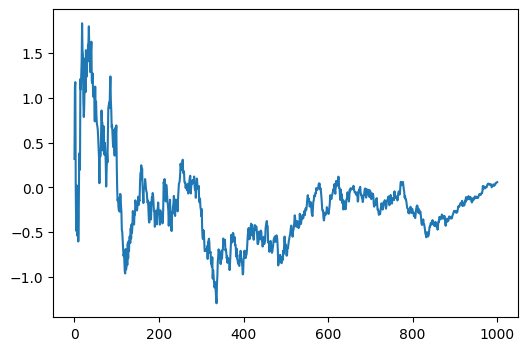

In [8]:
# plot a trajectory
y_t = torch.randn(1).to(device)
x = torch.ones_like(y_t) * 0.5
model.eval()
likelihood.eval()
traj = []
traj.append(y_t.item())
scores = []

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    for t in range(999, -1, -1):
        t_tensor = torch.ones_like(y_t) * (t+1)
        t_tensor = t_tensor / 1000
        z = torch.stack([x, t_tensor, y_t], dim=-1)
        score = likelihood(model(z)).mean
        # check if score hasn't changed for 3 consecutive times
        var = likelihood(model(z)).variance
        y_t = (1/torch.sqrt(diffusion.alphas[t+1])) * (y_t - ((1-diffusion.alphas[t+1])/torch.sqrt(1-diffusion.alphas_cumprod[t+1])) * score)
        y_t += torch.randn_like(y_t) * torch.sqrt(diffusion.betas[t])
        # y_t = torch.clamp(y_t, min=-3.0, max=3.0)
        traj.append(y_t.item())
        scores.append(score.item())
plt.figure(figsize=(6, 4))
plt.plot(traj)

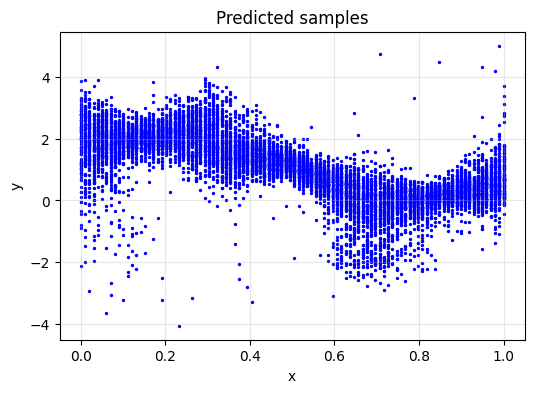

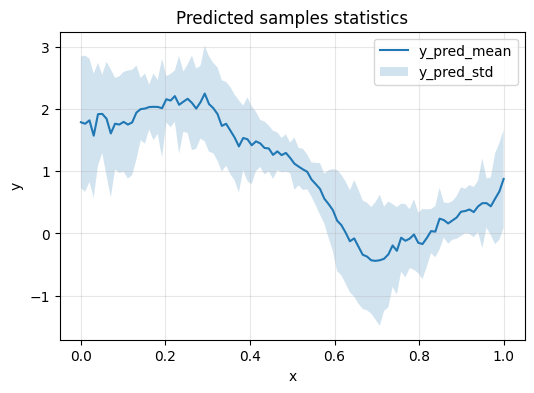

In [9]:
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples')
for i in range(results.shape[0]):
    plt.scatter(locations[i]*torch.ones(num_samples), results[i], s=2, c='b', label='y_t')
# plt.ylim(-2, 5)
# calculate the mean and std of the predicted samples
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted samples statistics')
y_pred_mean = np.mean(results, axis=1)
# get the variance of the predicted samples
y_pred_std = np.std(results, axis=1)
# plot the mean and std of the predicted samples
plt.plot(locations, y_pred_mean, label='y_pred_mean')
plt.fill_between(locations, y_pred_mean - y_pred_std, y_pred_mean + y_pred_std, alpha=0.2, label='y_pred_std')
plt.legend()

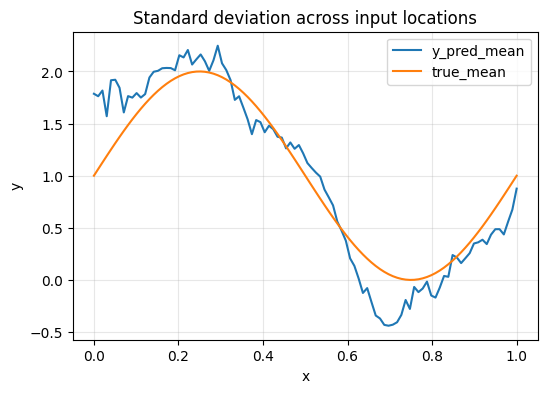

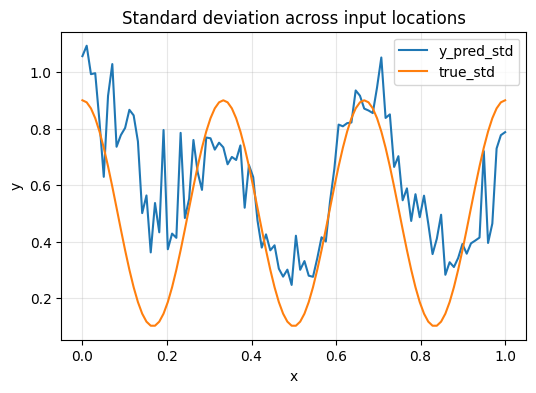

In [10]:
# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_mean, label='y_pred_mean')
# plot the true mean
plt.plot(locations, 1 + np.sin(2 * np.pi * locations), label='true_mean')
plt.legend()

# plot the standard deviation across input locations
plt.figure(figsize=(6, 4))
plt.grid(alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Standard deviation across input locations')
plt.plot(locations, y_pred_std, label='y_pred_std')
# plot the true standard deviation
plt.plot(locations, 0.5 + 0.4 * np.cos(6 * np.pi * locations), label='true_std')
# plt.ylim(-1, 1.5)
plt.legend()

# SGD GP